# Density-Based Clustering of AQI Patterns and Respiratory Disease Associations

**Major Project – SRM Institute of Science and Technology**

**Student 1:** Amit Hangargi  
**Student 2:** Rahul Manna  

**Guide:** Dr. Deeban Chakravarthy

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")

In [2]:
aqi_df = pd.read_csv("data/city_day.csv")
aqi_df.head() 

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
# Select required columns
aqi_df = aqi_df[[
    "City", "Date",
    "PM2.5", "PM10", "NO2", "SO2", "O3", "AQI"
]]

# Convert Date to datetime
aqi_df["Date"] = pd.to_datetime(aqi_df["Date"])

# Drop rows with missing values
aqi_df = aqi_df.dropna()

# Check cleaned data
aqi_df.head(), aqi_df.shape

(           City       Date  PM2.5    PM10    NO2     SO2     O3    AQI
 1595  Ahmedabad 2019-05-15  37.55  122.41  85.12  163.01  48.23  281.0
 1596  Ahmedabad 2019-05-16  33.97  116.32  79.71   91.26  51.86  330.0
 1597  Ahmedabad 2019-05-17  35.48  130.07  77.61   98.35  38.99  356.0
 1598  Ahmedabad 2019-05-18  34.11  138.31  75.23   88.66  42.22  359.0
 1599  Ahmedabad 2019-05-19  33.69  111.73  68.90   80.90  36.95  547.0,
 (16273, 8))

In [4]:
aqi_df.head() 

,City,Date,PM2.5,PM10,NO2,SO2,O3,AQI
1595,Ahmedabad,2019-05-15,37.55,122.41,85.12,163.01,48.23,281.0
1596,Ahmedabad,2019-05-16,33.97,116.32,79.71,91.26,51.86,330.0
1597,Ahmedabad,2019-05-17,35.48,130.07,77.61,98.35,38.99,356.0
1598,Ahmedabad,2019-05-18,34.11,138.31,75.23,88.66,42.22,359.0
1599,Ahmedabad,2019-05-19,33.69,111.73,68.90,80.90,36.95,547.0


In [5]:
aqi_df.shape

(16273, 8)

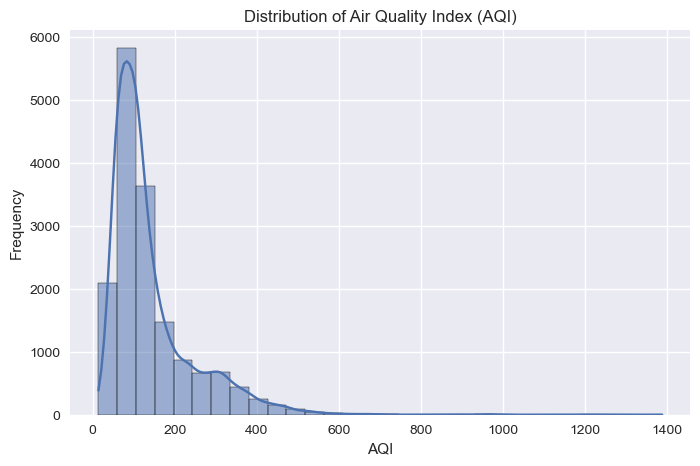

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(aqi_df["AQI"], bins=30, kde=True)
plt.title("Distribution of Air Quality Index (AQI)")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show() 

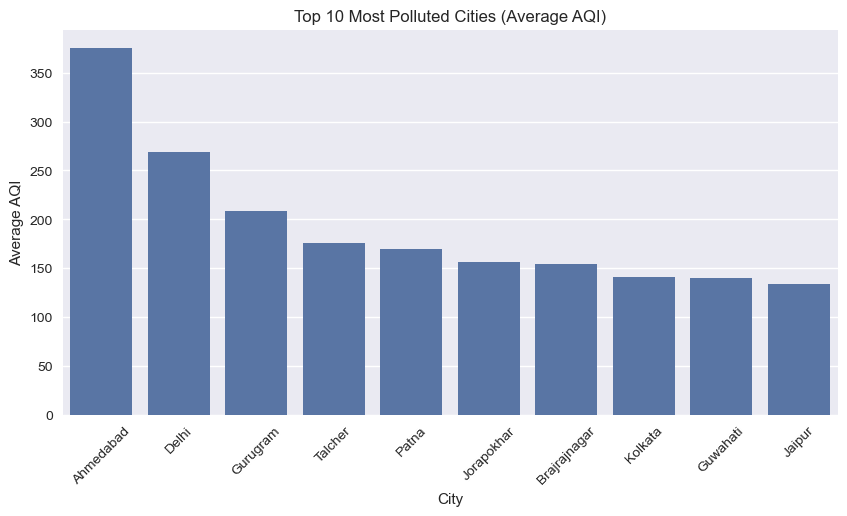

In [7]:
# Calculate average AQI per city
city_avg_aqi = (
    aqi_df.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

# Select top 10 most polluted cities
top_10_cities = city_avg_aqi.head(10)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_10_cities.index,
    y=top_10_cities.values
)
plt.title("Top 10 Most Polluted Cities (Average AQI)")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.show() 

In [8]:
aqi_df["City"].nunique(), aqi_df["City"].unique() 

(24,
 array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
        'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
        'Delhi', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur',
        'Jorapokhar', 'Kochi', 'Kolkata', 'Mumbai', 'Patna', 'Shillong',
        'Talcher', 'Thiruvananthapuram', 'Visakhapatnam'], dtype=object))

In [9]:
# Select features for clustering
features = aqi_df[["PM2.5", "PM10", "NO2", "SO2", "O3", "AQI"]]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Check shape
X_scaled.shape

(16273, 6)

In [10]:
# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.8, min_samples=10)

aqi_df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

# Check cluster distribution
aqi_df["dbscan_cluster"].value_counts() 

dbscan_cluster
 0    15252
-1     1001
 1       20
Name: count, dtype: int64

In [11]:
# Cluster-wise AQI statistics
cluster_stats = (
    aqi_df
    .groupby("dbscan_cluster")[["AQI", "PM2.5", "PM10", "NO2", "SO2", "O3"]]
    .mean()
)

cluster_stats

,AQI,PM2.5,PM10,NO2,SO2,O3
dbscan_cluster,,,,,,
-1,371.544456,141.050629,264.296414,65.357722,42.670470,56.035744
0,126.125426,51.930747,108.136758,26.437096,10.976222,33.891741
1,378.750000,92.734000,417.774500,2.217500,27.694000,10.659500


In [12]:
# Create health risk categories based on AQI
def health_risk(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

aqi_df["Health_Risk"] = aqi_df["AQI"].apply(health_risk)

# Check distribution
aqi_df["Health_Risk"].value_counts() 

Health_Risk
Satisfactory    6117
Moderate        5862
Poor            1624
Good            1131
Very Poor       1066
Severe           473
Name: count, dtype: int64

In [13]:
# Cluster-wise health risk distribution
cluster_health_risk = (
    aqi_df
    .groupby(["dbscan_cluster", "Health_Risk"])
    .size()
    .unstack(fill_value=0)
)

cluster_health_risk

Health_Risk,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
dbscan_cluster,,,,,,
-1,2,84,207,21,380,307
0,1129,5778,1416,6096,85,748
1,0,0,1,0,8,11


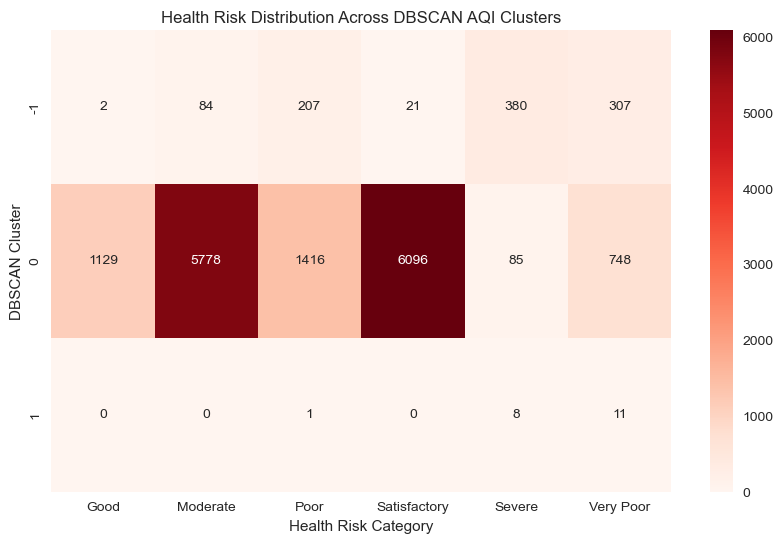

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_health_risk,
    annot=True,
    fmt="d",
    cmap="Reds"
)
plt.title("Health Risk Distribution Across DBSCAN AQI Clusters")
plt.xlabel("Health Risk Category")
plt.ylabel("DBSCAN Cluster")
plt.show() 